## Import Libs

In [1]:

# Import libraries
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
import seaborn as sns

# sns.set_style('darkgrid')

from pathlib import Path
# research_path = Path('../') # 'utils_functionality/')

import os
import sys
sys.path.append('../')

import utils_functionality.velocity_calculation as vc
import utils_functionality.sedimentation_calculation as sc

# from tqdm.notebook import tqdm
from tqdm import tqdm

beta here denotes exponent in the drag coefficient correction

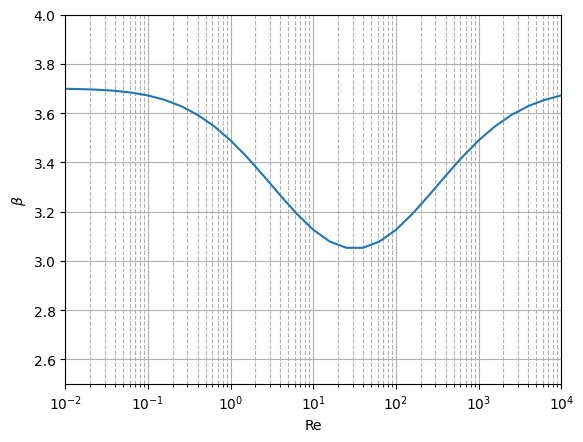

In [2]:
power = np.arange(-2, 5, step=0.2)
Re_vec = 10**power

beta = lambda Re: 3.7 - 0.65*np.exp(
        -0.5 * (1.5 - np.log10(Re))**2
    )

fig, ax = plt.subplots(1,1)
sns.lineplot(
    x=Re_vec,
    y=beta(Re_vec),
    ax=ax,
)

ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlim(1*10**-2, 10**4)
ax.set_ylim(2.5, 4)
ax.grid(which='minor', linestyle='--')
ax.grid(which='major')
ax.set_xlabel('Re')
ax.set_ylabel(r'$\beta$');

Compare with source plot [DiFelice1994VoidageFunction]:

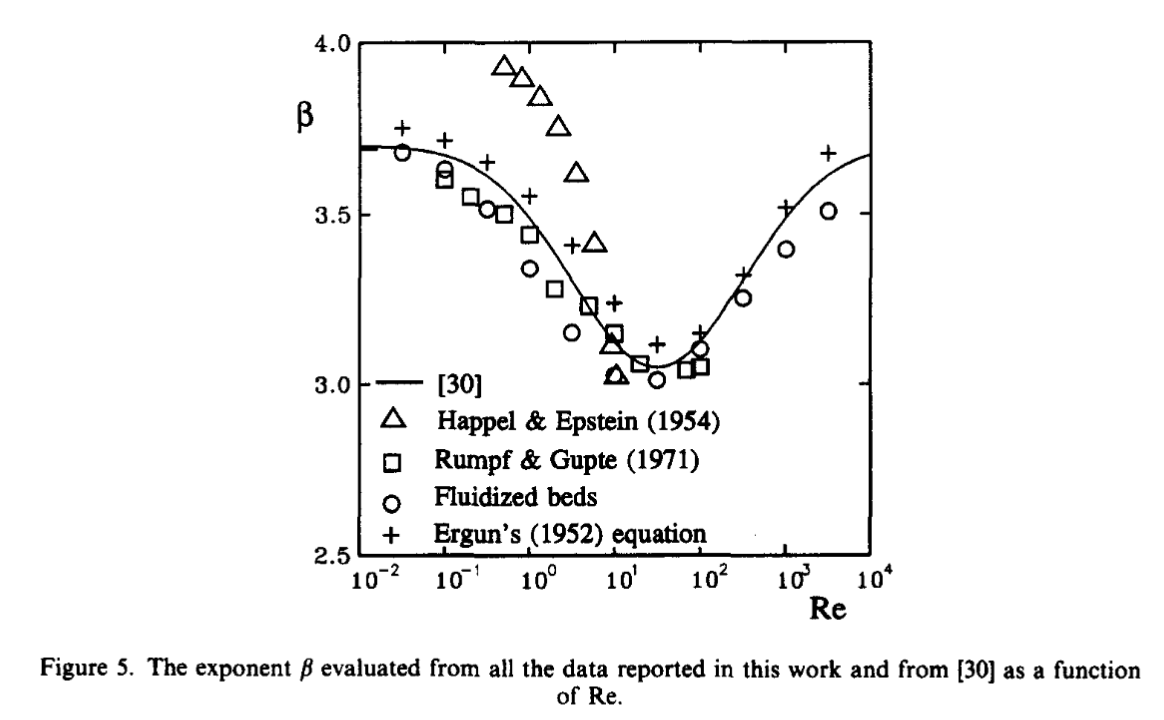

## Drag coefficient plot vs sedimentation drag coefficient plot

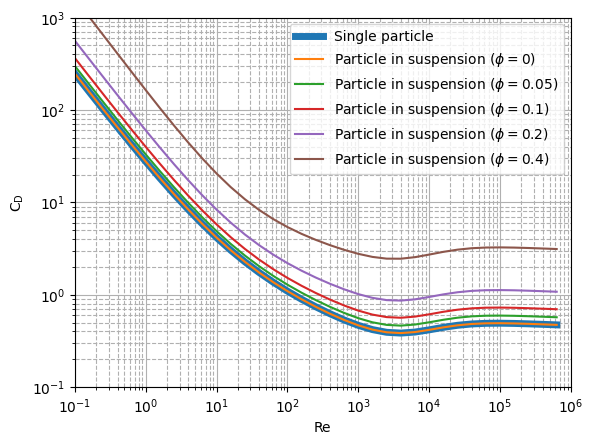

In [3]:
power = np.arange(-2, 6, step=0.2)
Re_vec = 10**power

fig, ax = plt.subplots(1,1)
sns.lineplot(
    x=Re_vec,
    y=vc.get_drag_coef(Re_vec),
    ax=ax,
    label='Single particle',
    linewidth=5,
)

phi = 0
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

phi = 0.05
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

phi = 0.10
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

phi = 0.20
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

phi = 0.40
sns.lineplot(
    x=Re_vec,
    y=sc.get_suspension_drag_coef(Re_vec, phi),
    ax=ax,
    label=f'Particle in suspension ($\phi=${phi})'
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1*10**-1, 10**6)
ax.set_ylim(10**-1, 10**3)
ax.grid(which='minor', linestyle='--')
ax.grid(which='major')
ax.set_xlabel('Re')
ax.set_ylabel('$\mathrm{C}_\mathrm{D}$')
ax.legend();

## Test Sedimentation System

Consider Oz oriented down.

SMALL GRID

In [4]:
d_p = 41.5e-6 # [m]
rho_l = 1180 # [kg/m^3]
mu_l = 23.1e-3 # [Pa*s]
eps_p = 2200/rho_l
init_phi = 0.10

g = 9.81 # [m/s^2]

h_exit = 10e-3 # [m]
N_L = 1001
N_E = 1001
N_BN = 2

z_p = np.linspace(0, h_exit, N_L)
v_p = np.zeros(N_L)

phi = init_phi*np.ones(N_E)
phi[0] = 0
q_phi = np.zeros(N_E)

init_state = np.hstack(
    (
        z_p,
        v_p,
        phi,
        q_phi
    )
)
# print(init_state.shape)

system = sc.SedimentationSystem(
    init_state=init_state,
    system_parameters_init = {
        "particle_size": d_p, # particle diameter [m]
        "particle_liquid_density_ratio": eps_p, # epsilon_p = rho_p/rho_l
        "density_liquid": rho_l, # [kg/m^3]
        "viscosity_liquid": mu_l, # Dynamic viscosity [Pa*s]
        "free_fall_acceleration": g, # gravitational acceleration [m/s^2]
        "height_exit": h_exit, # effective height of the sedimentation [m]
        "n_lagrangian_particles": N_L, # number of lagrangian particles
        "n_eulerian_nodes": N_E, # number of eulerian nodes
        "n_bottom_nodes": N_BN, # number of nodes to make another velocity profile
    }
)

t_span = (0, 2)
t_eval = np.linspace(*t_span, num=1000)
first_step = 1e-12
indicator_cnt = 1000
indicator_dt = (t_span[1] - t_span[0])/indicator_cnt

with tqdm(total=indicator_cnt, unit="‰") as pbar:
    numerical_results = solve_ivp(
        fun=system.compute_closed_loop_rhs,
        t_span=t_span, # s
        y0=system.init_state,
        t_eval=t_eval,
        first_step=first_step,
        method='RK45',
        args=[pbar, indicator_dt]
    )

index_t = 0
t = numerical_results.t[index_t]
print(f'INITIAL, t= {t} s')
z_p0, v_p0, phi0, q_phi0 = system.get_substates(
    numerical_results.y[:,index_t], verbose=True
)
print()

index_t = -1
t = numerical_results.t[index_t]
print(f'LAST, t= {t} s')
z_p_last, v_p_last, phi_last, q_phi_last = system.get_substates(
    numerical_results.y[:,index_t], verbose=True
)

  0%|          | 0/1000 [00:00<?, ?‰/s]

100%|█████████▉| 999/1000 [17:57<00:01,  1.08s/‰]

INITIAL, t= 0.0 s
z_p [m] = [0.00e+00 1.00e-05 2.00e-05 ... 9.98e-03 9.99e-03 1.00e-02]
v_p [m/s] = [0. 0. 0. ... 0. 0. 0.]
phi = [0.  0.1 0.1 ... 0.1 0.1 0.1]
q_phi [1/s] = [0. 0. 0. ... 0. 0. 0.]

LAST, t= 2.0 s
z_p [m] = [5.86379590e-05 6.61490257e-05 7.61124357e-05 ... 1.00351843e-02
 1.00460657e-02 1.00561210e-02]
v_p [m/s] = [2.80748191e-05 2.80595466e-05 2.80608128e-05 ... 2.80605857e-05
 2.80605857e-05 2.80605857e-05]
phi = [ 0.         -0.09902449 -0.14117168 ...  0.12208112  0.63853768
  0.1       ]
q_phi [1/s] = [ 0.          0.04385787 -0.2670129  ...  0.03629473  0.52329353
  0.        ]


In [6]:
def get_drop_height(
    D_drop, # [m]
    D_exit=1.6e-3, # default exit diameter of the syringe tip [m]
):
    drop_height = 2/3 * D_drop**3/D_exit**2
    
    return drop_height

h_drop = get_drop_height(
    D_drop=3e-3, 
)
print(f'Высота капли [m] = {h_drop:.4f}')
print(f'Доля высоты капли от высоты домена: {h_drop/h_exit:.3f}')

Высота капли [m] = 0.0070
Доля высоты капли от высоты домена: 0.703


In [7]:
import pandas as pd

pd.set_option('display.float_format', lambda x: '%.3e' % x)

# def get_substates(state, verbose=False, display_cnt=None):
#         """Get sub states of the state: particles position, their velocity, particle concentration, particle concentration change rate

#         Args:
#             state: full state
#             verbose: Print substates. Defaults to False.

#         Returns:
#             sub states of the state [z_p, v_p, phi, q_phi]
#         """
        
#         z_p = state[:N_L]
#         v_p = state[N_L:2*N_L]
#         phi = state[2*N_L:2*N_L+N_E]
#         q_phi = state[2*N_L+N_E:2*N_L+2*N_E]
        
#         if verbose:
#             if (display_cnt is None):   
#                 print(f'z_p [m] = {z_p}')
#                 print(f'v_p [m/s] = {v_p}')
#                 print(f'phi = {phi}')
#                 print(f'q_phi [1/s] = {q_phi}')
#             else:
#                 print(f'z_p [m] = {z_p[-display_cnt:]}')
#                 print(f'v_p [m/s] = {v_p[-display_cnt:]}')
#                 print(f'phi = {phi[-display_cnt:]}')
#                 print(f'q_phi [1/s] = {q_phi[-display_cnt:]}')
        
#         return z_p, v_p, phi, q_phi

index_t = 600
t = numerical_results.t[index_t]
print(f'INTERIM, t= {t} s')
z_p, v_p, phi, q_phi = system.get_substates(
    numerical_results.y[:,index_t], verbose=False
)
df = pd.DataFrame(
    {
        'z_p [m]': z_p,
        'v_p [m/s]': v_p,
        'phi': phi,
        'q_phi [1/s]': q_phi
    }
)

display(df.tail(15))

INTERIM, t= 1.2012012012012012 s


,z_p [m],v_p [m/s],phi,q_phi [1/s]
986,9.894e-03,2.806e-05,1.000e-01,0.000e+00
987,9.904e-03,2.806e-05,1.000e-01,0.000e+00
988,9.914e-03,2.806e-05,1.000e-01,0.000e+00
989,9.924e-03,2.806e-05,1.000e-01,0.000e+00
990,9.934e-03,2.806e-05,1.000e-01,0.000e+00
991,9.944e-03,2.806e-05,1.000e-01,0.000e+00
992,9.954e-03,2.806e-05,1.000e-01,0.000e+00
993,9.964e-03,2.806e-05,1.000e-01,1.683e-14
994,9.974e-03,2.790e-05,1.000e-01,1.039e-11
995,9.983e-03,2.116e-05,1.000e-01,4.137e-09


In [8]:
def get_all_substates(states):
        """Get sub states of the state: particles position, their velocity, particle concentration, particle concentration change rate

        Args:
            state: full state

        Returns:
            sub states of the state [z_p, v_p, phi, q_phi]
        """
        
        z_p = states[:N_L,:]
        v_p = states[N_L:2*N_L,:]
        phi = states[2*N_L:2*N_L+N_E,:]
        q_phi = states[2*N_L+N_E:2*N_L+2*N_E,:]
        
        return z_p, v_p, phi, q_phi

z_p, v_p, phi, q_phi = get_all_substates(numerical_results.y)
time = numerical_results.t

Check concentration

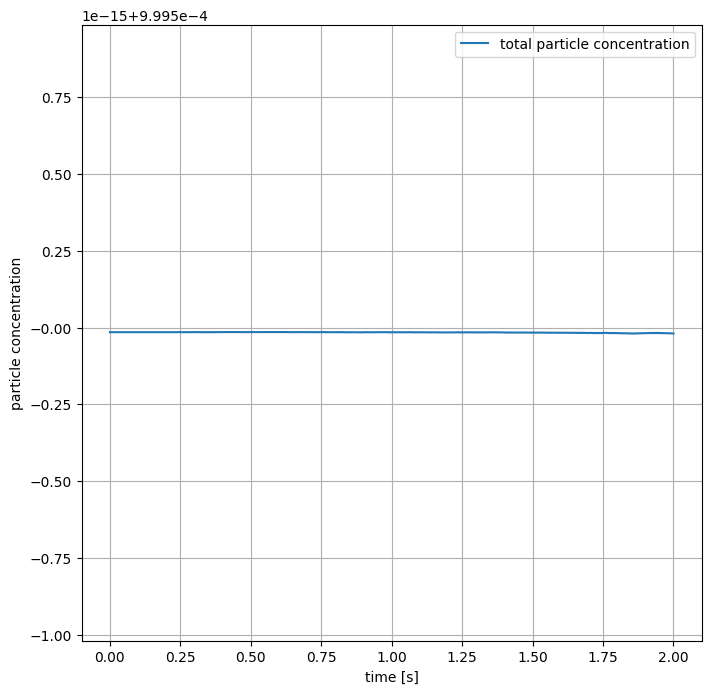

In [9]:
z_nodes = np.linspace(0, h_exit, N_E)

def integrate_phi(z_nodes, phi):
    integrals = np.trapz(
        phi,
        z_nodes,
        axis=0
    )
    
    return integrals

phi_integrals = integrate_phi(
    z_nodes=z_nodes,
    phi=phi
)


fig, ax = plt.subplots(1,1, figsize=(8,8))

ax.plot(
    time,
    phi_integrals,
    label=f'total particle concentration'
)

ax.set_xlabel('time [s]')
ax.set_ylabel('particle concentration')
ax.legend()
ax.grid()

In [10]:
(phi_integrals[-1] - phi_integrals[0])/phi_integrals[0]

-4.338978179031599e-15

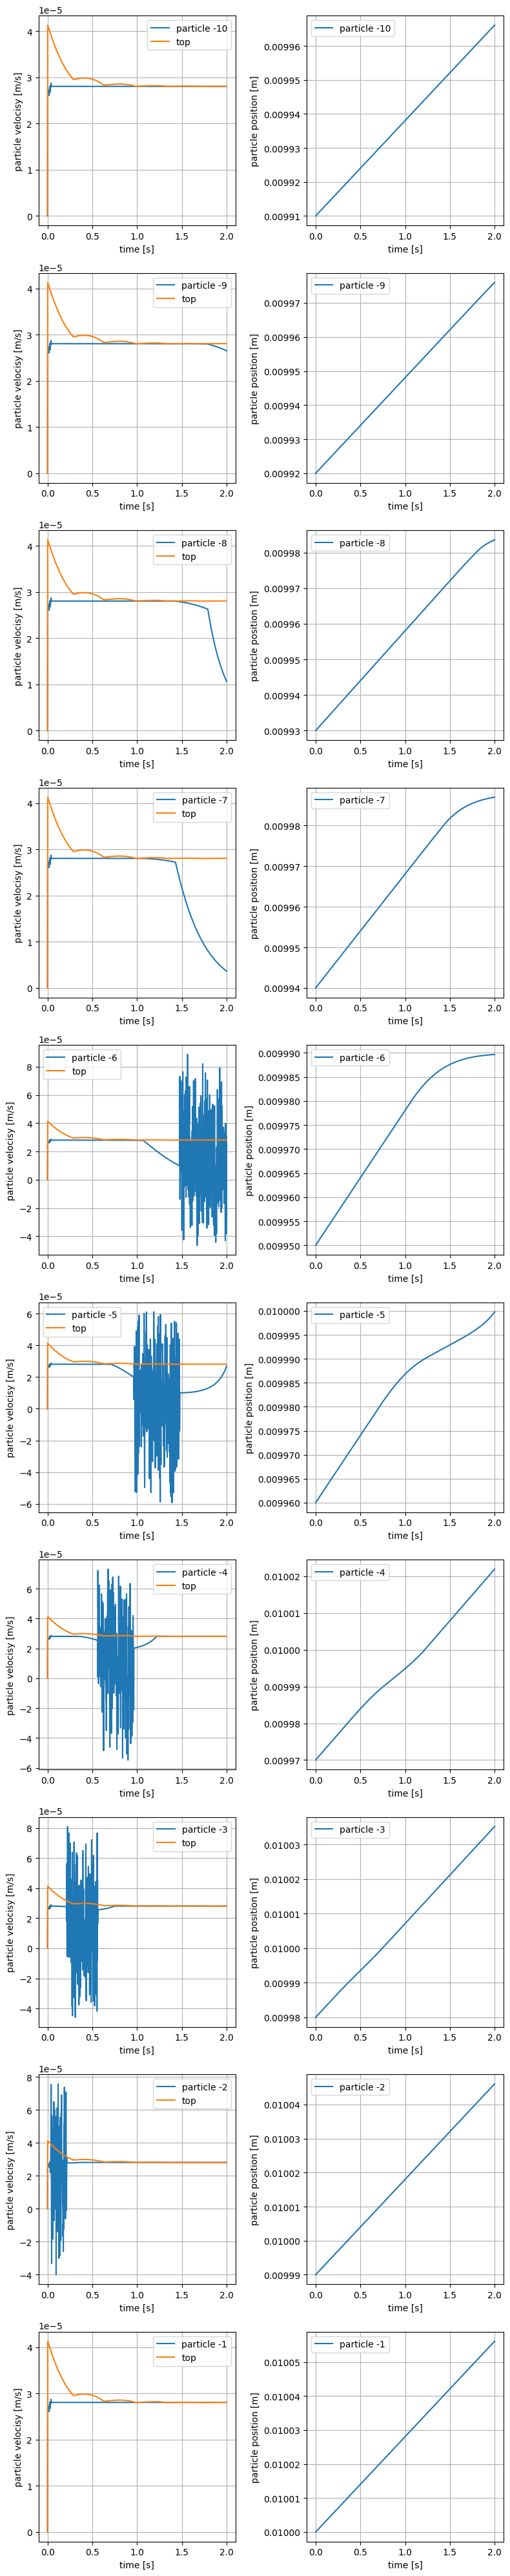

In [11]:
count = 10

fig, axes = plt.subplots(count,2, figsize=(4*2, count*4))
particles = np.arange(-count, 0)

for particle, vel_ax, pos_ax in zip(particles, axes[:,0], axes[:,1]):
    vel_ax.plot(
        time,
        v_p[particle,:],
        label=f'particle {particle}'
    )

    vel_ax.plot(
        time,
        v_p[0,:],
        label='top'
    )

    vel_ax.set_xlabel('time [s]')
    vel_ax.set_ylabel('particle velocisy [m/s]')
    vel_ax.legend()
    vel_ax.grid()
    
    pos_ax.plot(
        time,
        z_p[particle,:],
        label=f'particle {particle}'
    )

    # pos_ax.plot(
    #     time,
    #     z_p[0,:],
    #     label='top'
    # )

    pos_ax.set_xlabel('time [s]')
    pos_ax.set_ylabel('particle position [m]')
    pos_ax.legend()
    pos_ax.grid()
    
fig.tight_layout()

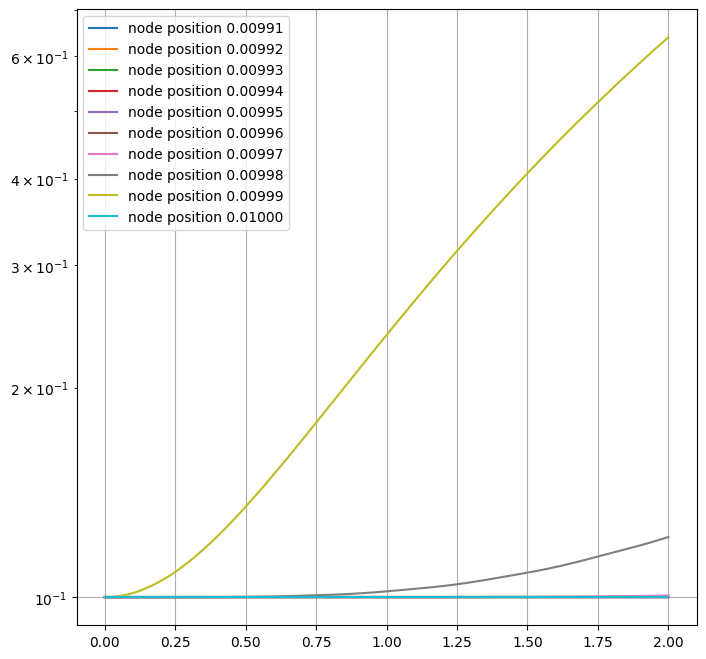

In [12]:
fig, ax = plt.subplots(1,1, figsize=(8,8))

nodes_cnt = 10
nodes = np.arange(-nodes_cnt, 0)

z_nodes = np.linspace(0, h_exit, N_E)

for node in nodes:
    ax.plot(
        time,
        phi[node,:],
        label=f'node position {z_nodes[node]:.5f}'
    )

ax.set_yscale('log')
pos_ax.set_xlabel('time [s]')
pos_ax.set_ylabel('particle concentration')
ax.legend()
ax.grid()

Droplet concentration changings

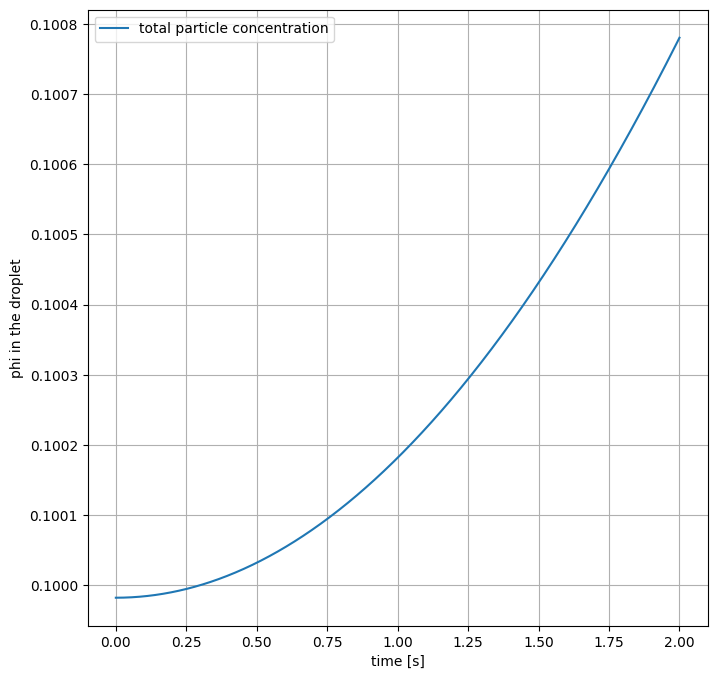

In [23]:
z_nodes = np.linspace(0, h_exit, N_E)

h_free = h_exit - h_drop

drop_mask = (z_nodes>h_free)

def integrate_phi(z_nodes, phi):
    integrals = np.trapz(
        phi,
        z_nodes,
        axis=0
    )
    
    return integrals

phi_integrals = integrate_phi(
    z_nodes=z_nodes[drop_mask],
    phi=phi[drop_mask]
)

drop_phi = phi_integrals/h_drop


fig, ax = plt.subplots(1,1, figsize=(8,8))

ax.plot(
    time,
    drop_phi,
    label=f'total particle concentration'
)

ax.set_xlabel('time [s]')
ax.set_ylabel('phi in the droplet')
ax.legend()
ax.grid()